# Basketball Models Dataset EDA

This notebook compares the **ball detector** and **player detector** datasets used to train:
- `models/ball_detector_model.pt`
- `models/player_detector.pt`

It performs:
- dataset structure checks
- class distribution analysis
- bounding box quality analysis
- image resolution analysis
- missing/invalid annotation checks
- lightweight model artifact inspection

In [2]:
# Optional (uncomment if needed)
%pip install pyyaml pandas matplotlib opencv-python ultralytics

from pathlib import Path
import yaml
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [11]:
# Resolve workspace/training directory robustly
cwd = Path.cwd()
if cwd.name == 'training_notebooks':
    WORKSPACE_ROOT = cwd.parent
    TRAINING_DIR = cwd
else:
    WORKSPACE_ROOT = cwd
    TRAINING_DIR = cwd / 'training_notebooks'

MODELS_DIR = WORKSPACE_ROOT / 'models'

print('Workspace root:', WORKSPACE_ROOT)
print('Training notebooks dir:', TRAINING_DIR)
print('Models dir:', MODELS_DIR)

Workspace root: d:\Basketball_analysis
Training notebooks dir: d:\Basketball_analysis\training_notebooks
Models dir: d:\Basketball_analysis\models


In [12]:
def discover_data_yaml_files(search_root: Path):
    if not search_root.exists():
        return []
    return sorted(search_root.rglob('data.yaml'))

all_data_yamls = discover_data_yaml_files(TRAINING_DIR)
print(f'Found {len(all_data_yamls)} data.yaml file(s) under training_notebooks:')
for i, p in enumerate(all_data_yamls, 1):
    print(f'  {i}. {p}')

Found 1 data.yaml file(s) under training_notebooks:
  1. d:\Basketball_analysis\training_notebooks\Basketball-Players-17\data.yaml


## Configure dataset YAMLs

If auto-discovery finds your two dataset `data.yaml` files, map them below.
If not found, set absolute or workspace-relative paths manually.

In [13]:
# Update these paths if needed
DATASET_YAML = {
    'ball_detector_model.pt': None,
    'player_detector.pt': None,
}

# Attempt a simple auto-fill heuristic
for y in all_data_yamls:
    low = str(y).lower()
    if DATASET_YAML['ball_detector_model.pt'] is None and ('ball' in low):
        DATASET_YAML['ball_detector_model.pt'] = y
    if DATASET_YAML['player_detector.pt'] is None and ('player' in low or 'players' in low):
        DATASET_YAML['player_detector.pt'] = y

# Fallback: first two discovered (if names are ambiguous)
remaining = [p for p in all_data_yamls if p not in DATASET_YAML.values()]
if DATASET_YAML['ball_detector_model.pt'] is None and remaining:
    DATASET_YAML['ball_detector_model.pt'] = remaining.pop(0)
if DATASET_YAML['player_detector.pt'] is None and remaining:
    DATASET_YAML['player_detector.pt'] = remaining.pop(0)

# If only one dataset YAML exists, use it for both analyses
if len(all_data_yamls) == 1:
    if DATASET_YAML['ball_detector_model.pt'] is None:
        DATASET_YAML['ball_detector_model.pt'] = all_data_yamls[0]
    if DATASET_YAML['player_detector.pt'] is None:
        DATASET_YAML['player_detector.pt'] = all_data_yamls[0]

print('Mapped datasets:')
for model_name, yaml_path in DATASET_YAML.items():
    print(f'  {model_name} -> {yaml_path}')

Mapped datasets:
  ball_detector_model.pt -> d:\Basketball_analysis\training_notebooks\Basketball-Players-17\data.yaml
  player_detector.pt -> d:\Basketball_analysis\training_notebooks\Basketball-Players-17\data.yaml


In [15]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

def resolve_path(base: Path, value, yaml_path: Path = None):
    p = Path(value)
    if p.is_absolute():
        return p

    candidates = []
    candidates.append((base / p).resolve())

    # handle YAMLs where split paths are written relative to YAML file
    if yaml_path is not None:
        candidates.append((yaml_path.parent / p).resolve())

    # handle duplicated dataset folder names e.g. Basketball-Players-17/Basketball-Players-17/train/images
    if len(p.parts) > 1:
        candidates.append((base / Path(*p.parts[1:])).resolve())
        if yaml_path is not None:
            candidates.append((yaml_path.parent / Path(*p.parts[1:])).resolve())

    for candidate in candidates:
        if candidate.exists():
            return candidate

    # fallback first candidate for transparency/debugging
    return candidates[0]

def load_dataset_config(yaml_path: Path):
    yaml_path = Path(yaml_path)
    with open(yaml_path, 'r', encoding='utf-8') as f:
        cfg = yaml.safe_load(f)

    names = cfg.get('names', {})
    if isinstance(names, list):
        names = {i: n for i, n in enumerate(names)}

    dataset_root = Path(cfg.get('path', yaml_path.parent))
    if not dataset_root.is_absolute():
        dataset_root = (yaml_path.parent / dataset_root).resolve()

    split_dirs = {}
    for split in ['train', 'val', 'test']:
        split_value = cfg.get(split)
        if split_value:
            split_dirs[split] = resolve_path(dataset_root, split_value, yaml_path=yaml_path)

    print(f'Loaded dataset config from: {yaml_path}')
    for split, split_dir in split_dirs.items():
        print(f'  {split}: {split_dir} (exists={Path(split_dir).exists()})')

    return {
        'yaml_path': yaml_path.resolve(),
        'dataset_root': dataset_root,
        'names': names,
        'nc': cfg.get('nc', len(names)),
        'splits': split_dirs,
    }

def _list_images(images_dir: Path):
    if not images_dir.exists():
        return []
    return sorted([p for p in images_dir.rglob('*') if p.suffix.lower() in IMAGE_EXTS])

def _list_labels(labels_dir: Path):
    if not labels_dir.exists():
        return []
    return sorted(labels_dir.rglob('*.txt'))

def analyze_split(split_name: str, split_path: Path, class_names: dict):
    split_path = Path(split_path)
    if split_path.name != 'images':
        images_dir = split_path
    else:
        images_dir = split_path

    labels_dir = images_dir.parent / 'labels'

    image_files = _list_images(images_dir)
    label_files = _list_labels(labels_dir)

    label_map = {lf.stem: lf for lf in label_files}

    rows = []
    missing_label_for_image = []
    invalid_label_rows = []

    for img_path in image_files:
        stem = img_path.stem
        lbl_path = label_map.get(stem)
        if lbl_path is None:
            missing_label_for_image.append(str(img_path))
            continue

        with open(lbl_path, 'r', encoding='utf-8') as f:
            lines = [ln.strip() for ln in f.readlines() if ln.strip()]

        if len(lines) == 0:
            continue

        for line_idx, line in enumerate(lines, 1):
            parts = line.split()
            if len(parts) != 5:
                invalid_label_rows.append({
                    'split': split_name,
                    'image': str(img_path),
                    'label_file': str(lbl_path),
                    'line_no': line_idx,
                    'line': line,
                    'reason': 'expected 5 columns'
                })
                continue

            try:
                class_id = int(float(parts[0]))
                x, y, w, h = map(float, parts[1:])
            except ValueError:
                invalid_label_rows.append({
                    'split': split_name,
                    'image': str(img_path),
                    'label_file': str(lbl_path),
                    'line_no': line_idx,
                    'line': line,
                    'reason': 'non-numeric value'
                })
                continue

            bbox_valid = (0 <= x <= 1) and (0 <= y <= 1) and (0 < w <= 1) and (0 < h <= 1)

            rows.append({
                'split': split_name,
                'image_path': str(img_path),
                'label_path': str(lbl_path),
                'class_id': class_id,
                'class_name': class_names.get(class_id, f'class_{class_id}'),
                'x_center': x,
                'y_center': y,
                'width': w,
                'height': h,
                'bbox_area': w * h,
                'aspect_ratio': (w / h) if h > 0 else np.nan,
                'bbox_valid': bbox_valid,
            })

    labels_without_images = []
    image_stems = {p.stem for p in image_files}
    for lbl in label_files:
        if lbl.stem not in image_stems:
            labels_without_images.append(str(lbl))

    return {
        'split': split_name,
        'images_dir': str(images_dir),
        'labels_dir': str(labels_dir),
        'n_images': len(image_files),
        'n_labels': len(label_files),
        'rows': rows,
        'missing_label_for_image': missing_label_for_image,
        'labels_without_images': labels_without_images,
        'invalid_label_rows': invalid_label_rows,
    }

def sample_image_sizes(image_paths, max_samples=300):
    if len(image_paths) > max_samples:
        image_paths = random.sample(image_paths, max_samples)

    sizes = []
    for p in image_paths:
        img = cv2.imread(str(p))
        if img is None:
            continue
        h, w = img.shape[:2]
        sizes.append((str(p), w, h, w / h if h > 0 else np.nan))
    return sizes

def run_dataset_eda(model_name: str, yaml_path: Path):
    ds = load_dataset_config(yaml_path)
    class_names = ds['names']

    split_reports = []
    all_rows = []

    for split, split_path in ds['splits'].items():
        report = analyze_split(split, split_path, class_names)
        split_reports.append(report)
        all_rows.extend(report['rows'])

    ann_df = pd.DataFrame(all_rows)

    split_summary = []
    for report in split_reports:
        split_name = report['split']
        split_df = ann_df[ann_df['split'] == split_name] if not ann_df.empty else pd.DataFrame()
        labeled_images = split_df['image_path'].nunique() if not split_df.empty else 0

        split_summary.append({
            'model': model_name,
            'split': split_name,
            'images': report['n_images'],
            'label_files': report['n_labels'],
            'labeled_images': labeled_images,
            'boxes': len(split_df),
            'avg_boxes_per_labeled_image': (len(split_df) / labeled_images) if labeled_images else 0,
            'missing_label_for_image': len(report['missing_label_for_image']),
            'labels_without_images': len(report['labels_without_images']),
            'invalid_rows': len(report['invalid_label_rows']),
            'invalid_bbox_rows': int((~split_df['bbox_valid']).sum()) if not split_df.empty else 0,
        })

    image_paths_for_sizes = []
    for split in ds['splits'].values():
        split = Path(split)
        image_paths_for_sizes.extend(_list_images(split))

    sizes = sample_image_sizes(image_paths_for_sizes, max_samples=300)
    size_df = pd.DataFrame(sizes, columns=['image_path', 'width_px', 'height_px', 'img_aspect_ratio'])

    issues = []
    for report in split_reports:
        issues.extend([{'type': 'missing_label_for_image', 'split': report['split'], 'path': p} for p in report['missing_label_for_image']])
        issues.extend([{'type': 'labels_without_images', 'split': report['split'], 'path': p} for p in report['labels_without_images']])
        issues.extend([{'type': 'invalid_label_row', **r} for r in report['invalid_label_rows']])

    issues_df = pd.DataFrame(issues)

    return {
        'model': model_name,
        'yaml_path': str(ds['yaml_path']),
        'dataset_root': str(ds['dataset_root']),
        'classes': class_names,
        'ann_df': ann_df,
        'split_summary_df': pd.DataFrame(split_summary),
        'size_df': size_df,
        'issues_df': issues_df,
    }

In [16]:
results = {}
for model_name, yaml_path in DATASET_YAML.items():
    if yaml_path is None:
        print(f'Skipping {model_name}: dataset YAML not set')
        continue
    yaml_path = Path(yaml_path)
    if not yaml_path.exists():
        print(f'Skipping {model_name}: missing file -> {yaml_path}')
        continue

    print(f'Running EDA for {model_name} ...')
    results[model_name] = run_dataset_eda(model_name, yaml_path)

print(f'Completed EDA for {len(results)} dataset(s).')

Running EDA for ball_detector_model.pt ...
Loaded dataset config from: d:\Basketball_analysis\training_notebooks\Basketball-Players-17\data.yaml
  train: D:\Basketball_analysis\training_notebooks\Basketball-Players-17\train\images (exists=True)
  val: D:\Basketball_analysis\training_notebooks\Basketball-Players-17\valid\images (exists=True)
  test: D:\Basketball_analysis\training_notebooks\Basketball-Players-17\test\images (exists=True)
Running EDA for player_detector.pt ...
Loaded dataset config from: d:\Basketball_analysis\training_notebooks\Basketball-Players-17\data.yaml
  train: D:\Basketball_analysis\training_notebooks\Basketball-Players-17\train\images (exists=True)
  val: D:\Basketball_analysis\training_notebooks\Basketball-Players-17\valid\images (exists=True)
  test: D:\Basketball_analysis\training_notebooks\Basketball-Players-17\test\images (exists=True)
Completed EDA for 2 dataset(s).


In [17]:
if results:
    summary_df = pd.concat([r['split_summary_df'] for r in results.values()], ignore_index=True)
    display(summary_df)
else:
    print('No dataset result available. Set DATASET_YAML and re-run.')

,model,split,images,label_files,labeled_images,boxes,avg_boxes_per_labeled_image,missing_label_for_image,labels_without_images,invalid_rows,invalid_bbox_rows
0,ball_detector_model.pt,train,256,256,256,3686,14.398438,0,0,0,0
1,ball_detector_model.pt,val,32,32,32,483,15.093750,0,0,0,0
2,ball_detector_model.pt,test,32,32,32,471,14.718750,0,0,0,0
3,player_detector.pt,train,256,256,256,3686,14.398438,0,0,0,0
4,player_detector.pt,val,32,32,32,483,15.093750,0,0,0,0
5,player_detector.pt,test,32,32,32,471,14.718750,0,0,0,0


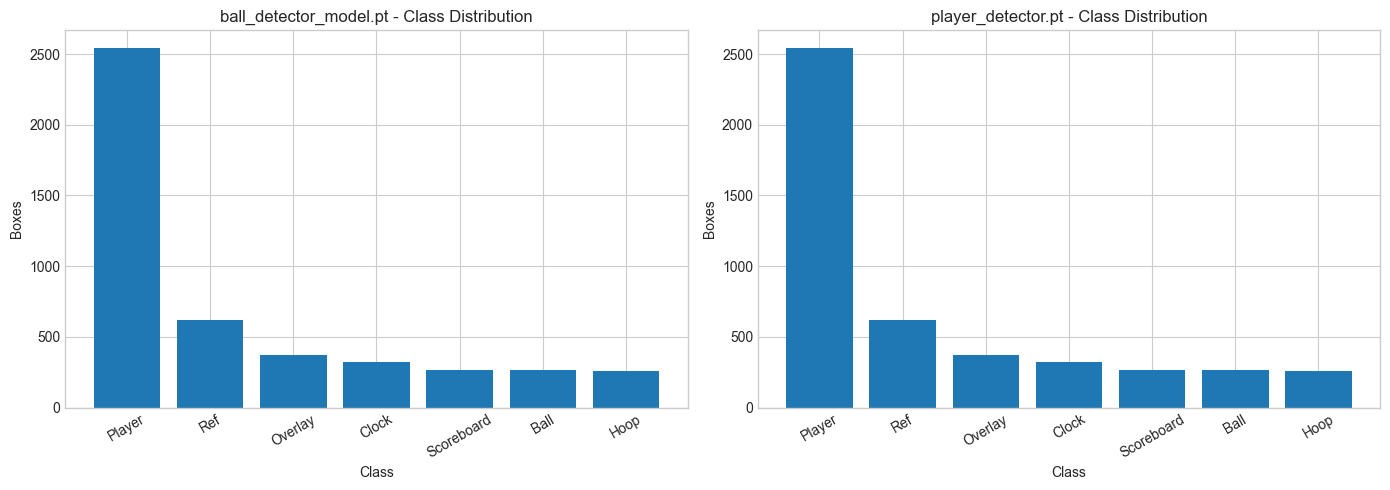

In [18]:
if results:
    fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 5), squeeze=False)
    for i, (model_name, out) in enumerate(results.items()):
        ax = axes[0, i]
        ann_df = out['ann_df']
        if ann_df.empty:
            ax.set_title(f'{model_name}: No annotations')
            ax.axis('off')
            continue

        class_counts = ann_df['class_name'].value_counts().reset_index()
        class_counts.columns = ['class_name', 'count']
        ax.bar(class_counts['class_name'], class_counts['count'])
        ax.set_title(f'{model_name} - Class Distribution')
        ax.set_xlabel('Class')
        ax.set_ylabel('Boxes')
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print('No plots: results empty.')

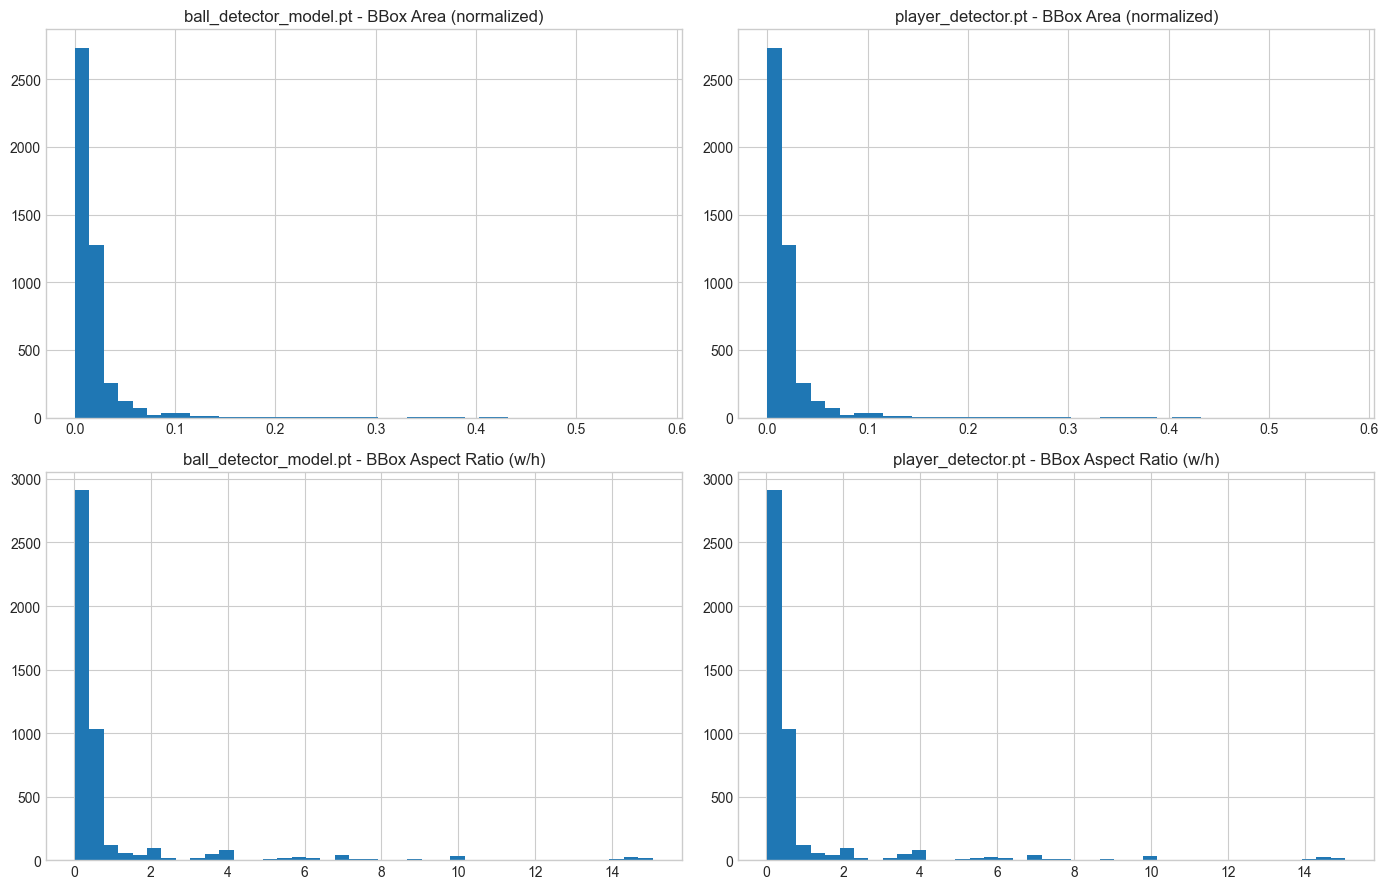

In [19]:
if results:
    fig, axes = plt.subplots(2, len(results), figsize=(7 * len(results), 9), squeeze=False)
    for i, (model_name, out) in enumerate(results.items()):
        ann_df = out['ann_df']

        if ann_df.empty:
            axes[0, i].set_title(f'{model_name}: No bbox areas')
            axes[0, i].axis('off')
            axes[1, i].set_title(f'{model_name}: No aspect ratios')
            axes[1, i].axis('off')
            continue

        axes[0, i].hist(ann_df['bbox_area'], bins=40)
        axes[0, i].set_title(f'{model_name} - BBox Area (normalized)')

        valid_ar = ann_df['aspect_ratio'].replace([np.inf, -np.inf], np.nan).dropna()
        axes[1, i].hist(valid_ar, bins=40)
        axes[1, i].set_title(f'{model_name} - BBox Aspect Ratio (w/h)')

    plt.tight_layout()
    plt.show()
else:
    print('No plots: results empty.')

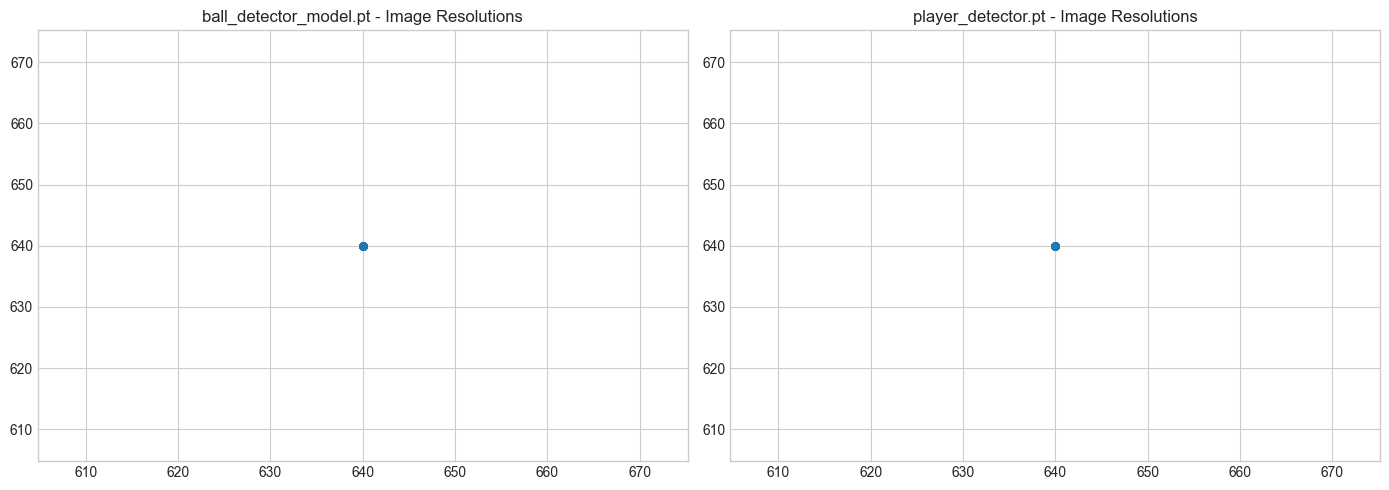

In [20]:
if results:
    fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 5), squeeze=False)
    for i, (model_name, out) in enumerate(results.items()):
        ax = axes[0, i]
        size_df = out['size_df']
        if size_df.empty:
            ax.set_title(f'{model_name}: No readable images')
            ax.axis('off')
            continue

        ax.scatter(size_df['width_px'], size_df['height_px'], s=25, alpha=0.6)
        ax.set_title(f'{model_name} - Image Resolutions')

    plt.tight_layout()
    plt.show()
else:
    print('No plots: results empty.')

In [21]:
for model_name, out in results.items():
    print('=' * 90)
    print(model_name)
    print('dataset_root:', out['dataset_root'])
    print('yaml_path:', out['yaml_path'])
    print('classes:', out['classes'])

    issues_df = out['issues_df']
    if issues_df.empty:
        print('No structural annotation issues detected.')
    else:
        print(f'Issues found: {len(issues_df)}')
        display(issues_df.head(20))

ball_detector_model.pt
dataset_root: d:\Basketball_analysis\training_notebooks\Basketball-Players-17
yaml_path: D:\Basketball_analysis\training_notebooks\Basketball-Players-17\data.yaml
classes: {0: 'Ball', 1: 'Clock', 2: 'Hoop', 3: 'Overlay', 4: 'Player', 5: 'Ref', 6: 'Scoreboard'}
No structural annotation issues detected.
player_detector.pt
dataset_root: d:\Basketball_analysis\training_notebooks\Basketball-Players-17
yaml_path: D:\Basketball_analysis\training_notebooks\Basketball-Players-17\data.yaml
classes: {0: 'Ball', 1: 'Clock', 2: 'Hoop', 3: 'Overlay', 4: 'Player', 5: 'Ref', 6: 'Scoreboard'}
No structural annotation issues detected.


## Model artifact quick inspection

This checks if the `.pt` model files exist, file size, and optionally loads metadata using Ultralytics.

In [22]:
model_paths = {
    'ball_detector_model.pt': MODELS_DIR / 'ball_detector_model.pt',
    'player_detector.pt': MODELS_DIR / 'player_detector.pt',
}

artifact_rows = []
for model_name, p in model_paths.items():
    artifact_rows.append({
        'model': model_name,
        'exists': p.exists(),
        'path': str(p),
        'size_mb': round(p.stat().st_size / (1024**2), 3) if p.exists() else np.nan,
        'modified': pd.to_datetime(p.stat().st_mtime, unit='s') if p.exists() else pd.NaT,
    })

artifact_df = pd.DataFrame(artifact_rows)
display(artifact_df)

# Optional deep metadata
try:
    from ultralytics import YOLO
    meta = []
    for model_name, p in model_paths.items():
        if not p.exists():
            continue
        model = YOLO(str(p))
        names = getattr(model.model, 'names', None)
        if names is None:
            names = getattr(model, 'names', None)
        meta.append({
            'model': model_name,
            'task': getattr(model, 'task', None),
            'num_classes_in_model': len(names) if isinstance(names, (dict, list)) else np.nan,
            'class_names': names,
        })

    if meta:
        display(pd.DataFrame(meta))
except Exception as e:
    print('Ultralytics metadata load skipped:', repr(e))

,model,exists,path,size_mb,modified
0,ball_detector_model.pt,True,d:\Basketball_analysis\models\ball_detector_mo...,164.670,2026-02-06 13:20:06.727136135
1,player_detector.pt,True,d:\Basketball_analysis\models\player_detector.pt,164.653,2026-02-05 12:14:00.682213783


,model,task,num_classes_in_model,class_names
0,ball_detector_model.pt,detect,7,"{0: 'Ball', 1: 'Clock', 2: 'Hoop', 3: 'Overlay..."
1,player_detector.pt,detect,7,"{0: 'Ball', 1: 'Clock', 2: 'Hoop', 3: 'Overlay..."


In [23]:
# Optional: export tabular EDA summaries
EXPORT_DIR = WORKSPACE_ROOT / 'runs' / 'eda_reports'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

if results:
    all_split_summary = pd.concat([r['split_summary_df'] for r in results.values()], ignore_index=True)
    all_split_summary.to_csv(EXPORT_DIR / 'split_summary.csv', index=False)

    all_issues = pd.concat([r['issues_df'].assign(model=m) for m, r in results.items() if not r['issues_df'].empty], ignore_index=True) if any(not r['issues_df'].empty for r in results.values()) else pd.DataFrame()
    if not all_issues.empty:
        all_issues.to_csv(EXPORT_DIR / 'issues.csv', index=False)

    all_ann = pd.concat([r['ann_df'].assign(model=m) for m, r in results.items() if not r['ann_df'].empty], ignore_index=True) if any(not r['ann_df'].empty for r in results.values()) else pd.DataFrame()
    if not all_ann.empty:
        all_ann.to_csv(EXPORT_DIR / 'all_annotations.csv', index=False)

print(f'EDA exports folder: {EXPORT_DIR}')

EDA exports folder: d:\Basketball_analysis\runs\eda_reports


In [26]:
from ultralytics import YOLO

EVAL_MODEL_PATHS = {
    'ball_detector_model.pt': MODELS_DIR / 'ball_detector_model.pt',
    'player_detector.pt': MODELS_DIR / 'player_detector.pt',
}

def _get_metric(rd, keys, default=np.nan):
    for key in keys:
        if key in rd and rd[key] is not None:
            return rd[key]
    return default

def build_clean_eval_yaml(original_yaml: Path):
    ds = load_dataset_config(original_yaml)
    out_dir = WORKSPACE_ROOT / 'runs' / 'eda_eval_data'
    out_dir.mkdir(parents=True, exist_ok=True)

    clean_cfg = {
        'path': str(ds['dataset_root']),
        'train': str(Path(ds['splits'].get('train', ''))),
        'val': str(Path(ds['splits'].get('val', ''))),
        'test': str(Path(ds['splits'].get('test', ''))) if 'test' in ds['splits'] else '',
        'names': ds['names'],
        'nc': ds['nc'],
    }

    # remove empty keys to avoid Ultralytics warnings
    clean_cfg = {k: v for k, v in clean_cfg.items() if v not in ['', None]}

    clean_yaml = out_dir / f"eval_{original_yaml.stem}.yaml"
    with open(clean_yaml, 'w', encoding='utf-8') as f:
        yaml.safe_dump(clean_cfg, f, sort_keys=False, allow_unicode=True)

    return clean_yaml

eval_rows = []
confusion_paths = {}

for model_name, model_path in EVAL_MODEL_PATHS.items():
    yaml_path = DATASET_YAML.get(model_name)

    if yaml_path is None:
        print(f'Skipping {model_name}: dataset YAML not mapped')
        continue

    yaml_path = Path(yaml_path)
    if not yaml_path.exists():
        print(f'Skipping {model_name}: missing YAML -> {yaml_path}')
        continue

    if not model_path.exists():
        print(f'Skipping {model_name}: missing model file -> {model_path}')
        continue

    eval_yaml = build_clean_eval_yaml(yaml_path)
    print(f'Validating {model_name} on cleaned YAML: {eval_yaml}')

    model = YOLO(str(model_path))
    val_results = model.val(
        data=str(eval_yaml),
        split='val',
        imgsz=640,
        plots=True,
        verbose=False,
        project=str(WORKSPACE_ROOT / 'runs' / 'eda_eval'),
        name=model_name.replace('.pt', ''),
        exist_ok=True,
    )

    rd = getattr(val_results, 'results_dict', {}) or {}

    row = {
        'model': model_name,
        'dataset_yaml': str(yaml_path),
        'eval_yaml_used': str(eval_yaml),
        'precision': _get_metric(rd, ['metrics/precision(B)', 'precision']),
        'recall': _get_metric(rd, ['metrics/recall(B)', 'recall']),
        'mAP50': _get_metric(rd, ['metrics/mAP50(B)', 'mAP50']),
        'mAP50_95': _get_metric(rd, ['metrics/mAP50-95(B)', 'mAP50-95']),
        'box_loss': _get_metric(rd, ['val/box_loss', 'box_loss']),
        'cls_loss': _get_metric(rd, ['val/cls_loss', 'cls_loss']),
        'dfl_loss': _get_metric(rd, ['val/dfl_loss', 'dfl_loss']),
        'accuracy_proxy_pct(mAP50)': np.nan,
    }

    if pd.notna(row['mAP50']):
        row['accuracy_proxy_pct(mAP50)'] = float(row['mAP50']) * 100.0

    eval_rows.append(row)

    save_dir = Path(getattr(val_results, 'save_dir', WORKSPACE_ROOT / 'runs' / 'eda_eval'))
    cm_candidates = [
        save_dir / 'confusion_matrix.png',
        save_dir / 'confusion_matrix_normalized.png',
    ]
    confusion_paths[model_name] = next((p for p in cm_candidates if p.exists()), None)

eval_df = pd.DataFrame(eval_rows)
display(eval_df)

if eval_df.empty:
    print('No evaluation results generated. Check model paths and DATASET_YAML mapping.')

Loaded dataset config from: d:\Basketball_analysis\training_notebooks\Basketball-Players-17\data.yaml
  train: D:\Basketball_analysis\training_notebooks\Basketball-Players-17\train\images (exists=True)
  val: D:\Basketball_analysis\training_notebooks\Basketball-Players-17\valid\images (exists=True)
  test: D:\Basketball_analysis\training_notebooks\Basketball-Players-17\test\images (exists=True)
Validating ball_detector_model.pt on cleaned YAML: d:\Basketball_analysis\runs\eda_eval_data\eval_data.yaml
Ultralytics 8.4.10  Python-3.12.10 torch-2.10.0+cpu CPU (AMD Ryzen 7 5800H with Radeon Graphics)
YOLOv5l6u summary (fused): 167 layers, 85,978,476 parameters, 0 gradients, 137.0 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 165.929.8 MB/s, size: 72.0 KB)
val: Scanning D:\Basketball_analysis\training_notebooks\Basketball-Players-17\valid\labels... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 1.4Kit/s 0.0s
val: New cache created: D:\Basketball_analysis\training_noteb

,model,dataset_yaml,eval_yaml_used,precision,recall,mAP50,mAP50_95,box_loss,cls_loss,dfl_loss,accuracy_proxy_pct(mAP50)
0,ball_detector_model.pt,d:\Basketball_analysis\training_notebooks\Bask...,d:\Basketball_analysis\runs\eda_eval_data\eval...,0.922246,0.899437,0.939238,0.752622,NaN,NaN,NaN,93.923815
1,player_detector.pt,d:\Basketball_analysis\training_notebooks\Bask...,d:\Basketball_analysis\runs\eda_eval_data\eval...,0.965132,0.922635,0.953038,0.793082,NaN,NaN,NaN,95.303834


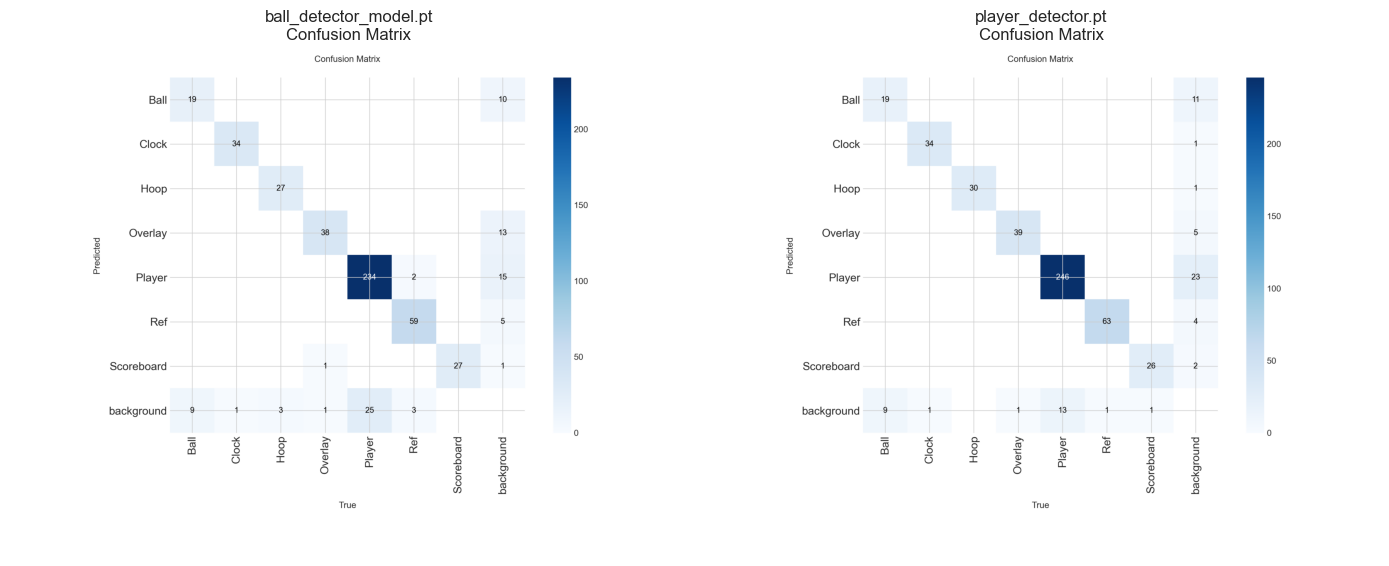

Note: loss columns are NaN because this Ultralytics validation output did not expose loss values.
You still have precision/recall/mAP and confusion matrices above.


In [27]:
if eval_rows:
    n = len(eval_rows)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6), squeeze=False)

    for i, row in enumerate(eval_rows):
        model_name = row['model']
        ax = axes[0, i]
        cm_path = confusion_paths.get(model_name)

        if cm_path is None or not Path(cm_path).exists():
            ax.set_title(f'{model_name}\nNo confusion matrix image found')
            ax.axis('off')
            continue

        img = plt.imread(str(cm_path))
        ax.imshow(img)
        ax.set_title(f'{model_name}\nConfusion Matrix')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    if eval_df[['box_loss', 'cls_loss', 'dfl_loss']].isna().all().all():
        print('Note: loss columns are NaN because this Ultralytics validation output did not expose loss values.')
        print('You still have precision/recall/mAP and confusion matrices above.')
else:
    print('No confusion matrices to display because evaluation did not run.')

## Model Validation Metrics (Accuracy, Loss, Confusion Matrix)

This section evaluates each `.pt` model on its mapped dataset YAML.

- **Accuracy proxy**: `mAP50` (object detection does not use simple classification accuracy)
- **Additional metrics**: precision, recall, mAP50-95
- **Losses**: validation losses when available from Ultralytics output
- **Confusion matrix**: loaded from validation artifacts

## Training Loss Curves from Training Runs

This section searches for Ultralytics training log files (`results.csv`) in the workspace.
If found, it plots train/val losses and prints final-epoch metrics per run.

In [30]:
def discover_training_result_csvs(root: Path):
    csvs = sorted(root.rglob('results.csv'))
    # Exclude notebook temp folders and virtual envs for speed/noise reduction
    csvs = [
        p for p in csvs
        if 'myenv' not in str(p).lower() and '.ipynb_checkpoints' not in str(p).lower()
    ]
    return csvs

def identify_loss_columns(df: pd.DataFrame):
    cols = list(df.columns)
    train_loss_cols = [c for c in cols if 'train/' in c and 'loss' in c.lower()]
    val_loss_cols = [c for c in cols if ('val/' in c and 'loss' in c.lower()) or ('metrics/' in c and 'loss' in c.lower())]
    if not train_loss_cols and not val_loss_cols:
        # fallback for alternative column naming
        train_loss_cols = [c for c in cols if c.lower().startswith('train') and 'loss' in c.lower()]
        val_loss_cols = [c for c in cols if c.lower().startswith('val') and 'loss' in c.lower()]
    return train_loss_cols, val_loss_cols

def identify_metric_columns(df: pd.DataFrame):
    cols = list(df.columns)
    preferred = [
        'metrics/precision(B)',
        'metrics/recall(B)',
        'metrics/mAP50(B)',
        'metrics/mAP50-95(B)',
        'metrics/precision',
        'metrics/recall',
        'metrics/mAP50',
        'metrics/mAP50-95',
    ]
    return [c for c in preferred if c in cols]

result_csvs = discover_training_result_csvs(WORKSPACE_ROOT)
print(f'Found {len(result_csvs)} training results.csv file(s).')
for i, p in enumerate(result_csvs, 1):
    print(f'  {i}. {p}')

if not result_csvs:
    print('No training logs found yet. If needed, copy/export run results.csv into the workspace and rerun this cell.')
else:
    summary_rows = []

    for csv_path in result_csvs:
        try:
            run_df = pd.read_csv(csv_path)
        except Exception as e:
            print(f'Skipping unreadable CSV: {csv_path} -> {e}')
            continue

        if run_df.empty:
            print(f'Skipping empty CSV: {csv_path}')
            continue

        epoch_col = 'epoch' if 'epoch' in run_df.columns else run_df.columns[0]
        train_loss_cols, val_loss_cols = identify_loss_columns(run_df)
        metric_cols = identify_metric_columns(run_df)

        run_name = csv_path.parent.name

        fig, ax = plt.subplots(figsize=(8, 5))
        plotted_any = False

        for c in train_loss_cols + val_loss_cols:
            ax.plot(run_df[epoch_col], run_df[c], label=c)
            plotted_any = True

        if plotted_any:
            ax.set_title(f'{run_name} - Training/Validation Loss Curves')
            ax.set_xlabel(epoch_col)
            ax.set_ylabel('Loss')
            ax.legend(loc='best', fontsize=8)
            ax.grid(alpha=0.25)
            plt.tight_layout()
            plt.show()
        else:
            plt.close(fig)
            print(f'No loss columns found in: {csv_path}')

        last = run_df.iloc[-1].to_dict()
        row = {
            'run_name': run_name,
            'results_csv': str(csv_path),
            'epochs_logged': int(len(run_df)),
        }
        for mc in metric_cols:
            row[mc] = last.get(mc, np.nan)
        for lc in train_loss_cols + val_loss_cols:
            row[f'final_{lc}'] = last.get(lc, np.nan)

        # accuracy proxy from final mAP50 if present
        map50_col = 'metrics/mAP50(B)' if 'metrics/mAP50(B)' in run_df.columns else ('metrics/mAP50' if 'metrics/mAP50' in run_df.columns else None)
        if map50_col is not None:
            m = last.get(map50_col, np.nan)
            row['accuracy_proxy_pct(mAP50)'] = float(m) * 100.0 if pd.notna(m) else np.nan

        summary_rows.append(row)

    if summary_rows:
        train_runs_summary_df = pd.DataFrame(summary_rows)
        display(train_runs_summary_df)
    else:
        print('No valid training run CSV summaries were generated.')

Found 0 training results.csv file(s).
No training logs found yet. If needed, copy/export run results.csv into the workspace and rerun this cell.


In [29]:
# Export current evaluation metrics (precision/recall/mAP + accuracy proxy)
EVAL_EXPORT_DIR = WORKSPACE_ROOT / 'runs' / 'eda_reports'
EVAL_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

if 'eval_df' in globals() and isinstance(eval_df, pd.DataFrame) and not eval_df.empty:
    eval_out = EVAL_EXPORT_DIR / 'model_eval_metrics.csv'
    eval_df.to_csv(eval_out, index=False)
    print(f'Evaluation metrics exported to: {eval_out}')
else:
    print('No eval_df found or it is empty. Run the validation metrics cell first, then rerun this cell.')

Evaluation metrics exported to: d:\Basketball_analysis\runs\eda_reports\model_eval_metrics.csv
